# 05 V2 - Layer B có ràng buộc, rerank và kiểm tra chất lượng

Notebook này là phiên bản mới, không thay đổi notebook 05 cũ và không ghi đè hai file knowledge gốc.

Luồng V2:

1. Audit và chuẩn hóa knowledge Layer B.
2. Tách intent thành các trường có cấu trúc.
3. Dùng category, mùa, hoàn cảnh, giới tính và profile làm filter.
4. Dùng BGE-M3 để lấy nhiều candidate, sau đó rerank minh bạch.
5. Chọn rule chi tiết cho toàn outfit thay vì lấy `exact[0]`.
6. Lấy sản phẩm Layer A có lọc subtype, department, mùa và chống lặp.
7. Kiểm tra bằng test case và báo `coverage_gap` khi knowledge không đủ.

> BGE-M3 vẫn phụ trách semantic retrieval của rule. ViFashionCLIP chỉ phụ trách tìm sản phẩm Layer A và ảnh tương tự.

> **Ranh giới kiến trúc:** notebook này không định nghĩa top-level router. Các helper tại đây chỉ suy ra constraint/retrieval goal bên trong một pipeline đã được `app/core/intent.py` chọn. Vì vậy chúng không làm tăng số business intent hay execution route.


## BƯỚC 0: Import và cấu hình

Nếu BGE-M3 chạy trên VastAI qua SSH tunnel, mở tunnel trước:

```powershell
ssh -N -L 11435:127.0.0.1:11434 root@124.60.192.12 -p 50044
```

Notebook sẽ tự chuyển sang chế độ lexical offline nếu Ollama hoặc Qdrant chưa sẵn sàng. Chế độ offline chỉ dùng để kiểm tra logic, không dùng để đánh giá chất lượng embedding.

### Định nghĩa thành phần: find_project_root

- **Tác dụng chính:** Khai báo `find_project_root` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `find_project_root` để cell thực thi phía sau tái sử dụng.


In [17]:
import base64
import hashlib
import html
import json
import mimetypes
import re
import sys
import unicodedata
import uuid
from collections import Counter, defaultdict
from copy import deepcopy
from pathlib import Path

import pandas as pd
import requests
from IPython.display import HTML, display
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, FieldCondition, Filter, MatchAny, MatchValue, VectorParams
from qdrant_client.models import PointStruct


def find_project_root(start: Path | None = None) -> Path:
    """Xử lý bước `find project root` của pipeline.

    Args:
        start (Path | None): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        Path: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "app" / "config.py").exists():
            return candidate
    raise RuntimeError("Không tìm thấy thư mục gốc Chatbot_Fashion")


### Thực thi và kiểm tra: PROJECT_ROOT

- **Tác dụng chính:** Chạy phần luồng phối đồ Layer B V2 tương ứng và giữ các dòng in/hiển thị cần thiết để debug.
- **Đầu vào (Input):** Các biến cấu hình, dữ liệu mẫu và đối tượng đã được định nghĩa ở các cell phía trên.
- **Đầu ra (Output):** Biến kết quả cùng output debug như shape, ID, score, trace hoặc trạng thái dịch vụ.


In [18]:
PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


### Định nghĩa thành phần: FEMALE_PATH, MALE_PATH, BGE_M3_BASE_URL

- **Tác dụng chính:** Khai báo `FEMALE_PATH`, `MALE_PATH`, `BGE_M3_BASE_URL`, `BGE_M3_MODEL` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `FEMALE_PATH`, `MALE_PATH`, `BGE_M3_BASE_URL`, `BGE_M3_MODEL` để cell thực thi phía sau tái sử dụng.


In [19]:
from app.config import PRODUCT_IMAGE_ROOT, QDRANT_URL
from app.core.image_search import resolve_main_image_path, search_products_by_image
from app.core.vector_store import get_product_vector_db, normalize_product_metadata

FEMALE_PATH = PROJECT_ROOT / "data" / "stylists" / "Layer_B_Female_Knowledge.json"
MALE_PATH = PROJECT_ROOT / "data" / "stylists" / "Layer_B_Male_Knowledge.json"

BGE_M3_BASE_URL = "http://127.0.0.1:11435"
BGE_M3_MODEL = "bge-m3"
LAYER_B_COLLECTION_PREFIX = "layer_b_v2"

# Các bước ngoài có try/except và sẽ không làm notebook dừng nếu dịch vụ chưa chạy.
ENABLE_LAYER_B_INDEX = False
ENABLE_LAYER_A_PRODUCTS = True
ENABLE_IMAGE_DEMO = True


### Thực thi và kiểm tra: luồng phối đồ Layer B V2

- **Tác dụng chính:** Chạy phần luồng phối đồ Layer B V2 tương ứng và giữ các dòng in/hiển thị cần thiết để debug.
- **Đầu vào (Input):** Các biến cấu hình, dữ liệu mẫu và đối tượng đã được định nghĩa ở các cell phía trên.
- **Đầu ra (Output):** Biến kết quả cùng output debug như shape, ID, score, trace hoặc trạng thái dịch vụ.


In [20]:
print(f"[OK] Project: {PROJECT_ROOT}")
print(f"[INFO] BGE-M3: {BGE_M3_BASE_URL} | model={BGE_M3_MODEL}")


[OK] Project: D:\KHÓA LUẬN\WORKSPACE\Chatbot_Fashion
[INFO] BGE-M3: http://127.0.0.1:11435 | model=bge-m3


## BƯỚC 1: Nạp và audit knowledge gốc

Mục tiêu của bước này là phát hiện coverage thiếu, taxonomy trùng tên và nhóm rule có nhiều lựa chọn. Không chỉnh dữ liệu ở bước này.

### Định nghĩa thành phần: load_json

- **Tác dụng chính:** Khai báo `load_json` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `load_json` để cell thực thi phía sau tái sử dụng.


In [21]:
def load_json(path: Path) -> list[dict]:
    return json.loads(path.read_text(encoding="utf-8-sig"))


### Thực thi và kiểm tra: raw_female, raw_male

- **Tác dụng chính:** Chạy phần luồng phối đồ Layer B V2 tương ứng và giữ các dòng in/hiển thị cần thiết để debug.
- **Đầu vào (Input):** Các biến cấu hình, dữ liệu mẫu và đối tượng đã được định nghĩa ở các cell phía trên.
- **Đầu ra (Output):** Biến kết quả cùng output debug như shape, ID, score, trace hoặc trạng thái dịch vụ.


In [22]:
raw_female = load_json(FEMALE_PATH)
raw_male = load_json(MALE_PATH)


### Định nghĩa thành phần: split_rule_key, audit_raw_rules

- **Tác dụng chính:** Khai báo `split_rule_key`, `audit_raw_rules` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `split_rule_key`, `audit_raw_rules` để cell thực thi phía sau tái sử dụng.


In [23]:
def split_rule_key(rule_key: str) -> tuple[str, str]:
    parts = str(rule_key or "").split("|", 1)
    slot = parts[0].strip()
    item_archetype = parts[1].strip() if len(parts) > 1 else ""
    return slot, item_archetype


def audit_raw_rules(data: list[dict], gender: str) -> dict:
    """Xử lý bước `audit raw rules` của pipeline.

    Args:
        data (list[dict]): Giá trị đầu vào phục vụ bước xử lý này.
        gender (str): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    styles = Counter(str(row.get("phong_cach", "")).strip() for row in data)
    contexts = Counter(str(row.get("boi_canh", "")).strip() for row in data)
    slots = Counter(split_rule_key(row.get("rule_key", ""))[0] for row in data)
    groups = Counter(
        (
            split_rule_key(row.get("rule_key", ""))[0],
            str(row.get("phong_cach", "")).strip(),
            str(row.get("boi_canh", "")).strip(),
        )
        for row in data
    )
    own_slot = sum(
        split_rule_key(row.get("rule_key", ""))[0] in (row.get("goi_y_phoi_cung") or [])
        for row in data
    )
    return {
        "gender": gender,
        "total_rules": len(data),
        "styles": len(styles),
        "contexts": len(contexts),
        "slots": len(slots),
        "multi_option_groups": sum(count > 1 for count in groups.values()),
        "max_options_in_group": max(groups.values()),
        "recommendation_contains_base": own_slot,
        "recommendation_contains_base_rate": round(own_slot / max(len(data), 1), 4),
        "style_values": sorted(styles),
        "context_values": sorted(contexts),
    }


### Thực thi và kiểm tra: raw_audit

- **Tác dụng chính:** Chạy phần luồng phối đồ Layer B V2 tương ứng và giữ các dòng in/hiển thị cần thiết để debug.
- **Đầu vào (Input):** Các biến cấu hình, dữ liệu mẫu và đối tượng đã được định nghĩa ở các cell phía trên.
- **Đầu ra (Output):** Biến kết quả cùng output debug như shape, ID, score, trace hoặc trạng thái dịch vụ.


In [24]:
raw_audit = pd.DataFrame([
    audit_raw_rules(raw_female, "female"),
    audit_raw_rules(raw_male, "male"),
])
display(raw_audit.drop(columns=["style_values", "context_values"]))

print("\nPhong cách nữ:", raw_audit.iloc[0]["style_values"])
print("\nBối cảnh nữ:", raw_audit.iloc[0]["context_values"])
print("\n[NHẬN XÉT] Nếu một mùa không xuất hiện ở đây, V2 sẽ báo thiếu coverage thay vì trả mùa khác.")


,gender,total_rules,styles,contexts,slots,multi_option_groups,max_options_in_group,recommendation_contains_base,recommendation_contains_base_rate
0,female,880,24,15,8,184,13,144,0.1636
1,male,416,11,25,8,82,14,57,0.1370



Phong cách nữ: ['Casual', 'Casual Denim', 'Denim casual', 'Edgy Street', 'Edgy street', 'Edgy streetwear', 'Elevated commute', 'Mature urban', 'Minimalist Neutral', 'Minimalist neutral', 'Premium commute', 'Professional commute', 'Smart urban', 'Sophisticated Commuter', 'Sophisticated commute', 'Sophisticated urban', 'Sweet & Cool', 'Sweet-cool', 'Sweet-cool girl', 'Trendy street avant-garde', 'Urban Chic', 'Vintage Preppy', 'Vintage collegiate', 'Vintage preppy']

Bối cảnh nữ: ['Mùa thu – Công sở', 'Mùa thu – Du lịch', 'Mùa thu – Học đường', 'Mùa thu – Xã hội', 'Mùa thu – Ở nhà', 'Mùa đông – Công sở', 'Mùa đông – Du lịch', 'Mùa đông – Học đường', 'Mùa đông – Xã hội', 'Mùa đông – Ở nhà', 'Thu đông – Công sở', 'Thu đông – Du lịch', 'Thu đông – Học đường', 'Thu đông – Xã hội', 'Thu đông – Ở nhà']

[NHẬN XÉT] Nếu một mùa không xuất hiện ở đây, V2 sẽ báo thiếu coverage thay vì trả mùa khác.


## BƯỚC 2: Chuẩn hóa taxonomy và kiểm tra nhãn

Bản chuẩn hóa bổ sung các trường riêng: `outfit_slot`, `item_archetype`, `style`, `season_tokens`, `occasion`, `body_types`, `skin_tones`, `suggested_slots` và `rule_id`.

`rule_key` được giữ lại để truy vết, nhưng không còn bị dùng đồng thời như ID, category và toàn bộ logic tìm kiếm.

### Định nghĩa thành phần: STYLE_ALIASES, SEASON_COMPONENTS, ascii_text

- **Tác dụng chính:** Khai báo `STYLE_ALIASES`, `SEASON_COMPONENTS`, `ascii_text`, `canonical_style` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `STYLE_ALIASES`, `SEASON_COMPONENTS`, `ascii_text`, `canonical_style` để cell thực thi phía sau tái sử dụng.


In [25]:
STYLE_ALIASES = {
    "edgy street": "Edgy streetwear",
    "edgy streetwear": "Edgy streetwear",
    "minimalist neutral": "Minimalist neutral",
    "sweet & cool": "Sweet-cool",
    "sweet-cool girl": "Sweet-cool",
    "vintage preppy": "Vintage preppy",
    "sophisticated commuter": "Sophisticated commute",
    "quiet luxury": "Quiet luxury old money",
}

SEASON_COMPONENTS = {
    "Xuân": {"Xuân"},
    "Hè": {"Hè"},
    "Thu": {"Thu"},
    "Đông": {"Đông"},
    "Xuân hè": {"Xuân", "Hè"},
    "Thu đông": {"Thu", "Đông"},
}


def ascii_text(value: str) -> str:
    text = unicodedata.normalize("NFD", str(value or "").lower())
    text = "".join(ch for ch in text if unicodedata.category(ch) != "Mn")
    return re.sub(r"\s+", " ", text.replace("đ", "d")).strip()


def canonical_style(value: str) -> str:
    clean = str(value or "").strip()
    return STYLE_ALIASES.get(clean.lower(), clean)


def canonical_profile_value(value: str) -> str:
    """Xử lý bước `canonical profile value` của pipeline.

    Args:
        value (str): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        str: Kết quả đã xử lý của hàm.
    """
    clean = str(value or "").strip()
    lowered = clean.lower()
    prefixes = [
        "Mọi vóc dáng", "Mọi tone da", "Người thấp bé", "Người ngoại cỡ",
        "Người mảnh", "Người đậm người", "Người đùi to", "Dáng quả lê",
        "Dáng quả táo", "Dáng đồng hồ cát", "Dáng chữ nhật", "Dáng cân đối",
        "Da sáng", "Da trung bình", "Da ngăm", "Da ấm",
    ]
    for prefix in prefixes:
        if lowered.startswith(prefix.lower()):
            return prefix
    return clean


def canonical_list(value, normalizer=lambda x: str(x).strip()) -> list[str]:
    """Xử lý bước `canonical list` của pipeline.

    Args:
        value (Any): Giá trị đầu vào phục vụ bước xử lý này.
        normalizer (Any): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        list[str]: Kết quả đã xử lý của hàm.
    """
    values = value if isinstance(value, list) else [value]
    result = []
    for item in values:
        normalized = normalizer(item)
        if normalized and normalized not in result:
            result.append(normalized)
    return result


def parse_context(value: str) -> tuple[str, list[str], str]:
    """Xử lý bước `parse context` của pipeline.

    Args:
        value (str): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        tuple[str, list[str], str]: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    parts = re.split(r"\s*[–—-]\s*", str(value or "").strip(), maxsplit=1)
    season_raw = parts[0].replace("Mùa ", "").strip()
    occasion = parts[1].strip() if len(parts) > 1 else ""
    season_map = {
        "xuân": "Xuân", "hè": "Hè", "thu": "Thu", "đông": "Đông",
        "xuân hè": "Xuân hè", "thu đông": "Thu đông",
    }
    season = season_map.get(season_raw.lower(), season_raw)
    return season, sorted(SEASON_COMPONENTS.get(season, {season})), occasion


STRONG_ITEM_PATTERNS = [
    ("Phụ kiện", ["beret", "beanie", "fedora", "bucket hat", "baseball cap", "sunglasses", "earring", "necklace", "bracelet", "brooch", "gloves", "scarf", "belt"]),
    ("Giày dép", ["shoes", "shoe", "boots", "boot", "sneaker", "loafer", "sandals", "slipper", "pumps", "heels", "mules"]),
    ("Túi xách", ["handbag", "shoulder bag", "tote bag", "crossbody bag", "clutch", "backpack"]),
    ("Đầm/Jumpsuit", ["jumpsuit", "dress"]),
    ("Quần/Chân váy", ["trousers", "pants", "jeans", "shorts", "mini skirt", "midi skirt", "maxi skirt", "pleated skirt"]),
    ("Áo khoác ngoài", ["trench coat", "wool coat", "down jacket", "bomber jacket", "blazer", "parka", "puffer", "windbreaker"]),
    ("Áo khoác nhẹ/Áo len", ["cardigan", "pullover", "sweater", "hoodie"]),
    ("Áo mặc trong (áo thun/sơ mi)", ["tank top", "t-shirt", "tee shirt", "blouse", "polo shirt", "camisole"]),
]


def infer_strong_slot(item_archetype: str) -> tuple[str | None, str | None]:
    """Xử lý bước `infer strong slot` của pipeline.

    Args:
        item_archetype (str): Bản ghi sản phẩm hoặc đối tượng đang xử lý.

    Returns:
        tuple[str | None, str | None]: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    text = ascii_text(item_archetype)
    for slot, patterns in STRONG_ITEM_PATTERNS:
        for pattern in patterns:
            normalized_pattern = ascii_text(pattern)
            if re.search(rf"(?<![a-z0-9]){re.escape(normalized_pattern)}(?![a-z0-9])", text):
                return slot, pattern
    return None, None


def qa_severity(expected_slot: str, inferred_slot: str | None, evidence: str | None) -> str:
    """Xử lý bước `qa severity` của pipeline.

    Args:
        expected_slot (str): Giá trị đầu vào phục vụ bước xử lý này.
        inferred_slot (str | None): Giá trị đầu vào phục vụ bước xử lý này.
        evidence (str | None): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        str: Kết quả đã xử lý của hàm.
    """
    if not inferred_slot or inferred_slot == expected_slot:
        return "none"
    adjacent_pairs = {
        frozenset({"Áo khoác ngoài", "Áo khoác nhẹ/Áo len"}),
    }
    if frozenset({expected_slot, inferred_slot}) in adjacent_pairs:
        return "medium"
    if {expected_slot, inferred_slot} == {"Áo mặc trong (áo thun/sơ mi)", "Áo khoác nhẹ/Áo len"} and evidence in {"sweater", "cardigan", "pullover"}:
        return "medium"
    return "high"


def context_qa_issue(item_archetype: str, season_tokens: list[str], occasion: str) -> tuple[str, str]:
    """Xử lý bước `context qa issue` của pipeline.

    Args:
        item_archetype (str): Bản ghi sản phẩm hoặc đối tượng đang xử lý.
        season_tokens (list[str]): Giá trị đầu vào phục vụ bước xử lý này.
        occasion (str): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        tuple[str, str]: Kết quả đã xử lý của hàm.
    """
    text = ascii_text(item_archetype)
    if "slipper" in text and occasion != "Ở nhà":
        return "high", "slipper không phù hợp bối cảnh ngoài nhà"
    if "Đông" in season_tokens and any(term in text for term in ["open-back", "sandal"]):
        return "high", "giày hở hoặc sandal không phù hợp mùa đông"
    if "Hè" in season_tokens and any(term in text for term in ["down jacket", "wool coat", "faux fur coat"]):
        return "high", "áo giữ nhiệt dày không phù hợp mùa hè"
    if occasion == "Thể thao" and any(term in text for term in ["high heel", "stiletto", "evening clutch"]):
        return "high", "món đồ không phù hợp hoạt động thể thao"
    return "none", ""


def normalize_rule(row: dict, gender: str) -> dict:
    """Xử lý bước `normalize rule` của pipeline.

    Args:
        row (dict): Giá trị đầu vào phục vụ bước xử lý này.
        gender (str): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.

    Returns:
        dict: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    slot, item_archetype = split_rule_key(row.get("rule_key", ""))
    season, season_tokens, occasion = parse_context(row.get("boi_canh", ""))
    inferred_slot, evidence = infer_strong_slot(item_archetype)
    category_severity = qa_severity(slot, inferred_slot, evidence)
    context_severity, context_issue = context_qa_issue(item_archetype, season_tokens, occasion)
    severity_order = {"none": 0, "medium": 1, "high": 2}
    severity = max([category_severity, context_severity], key=severity_order.get)
    suggested_slots = []
    for suggested in row.get("goi_y_phoi_cung") or []:
        suggested = str(suggested).strip()
        if suggested and suggested != slot and suggested not in suggested_slots:
            suggested_slots.append(suggested)

    identity = "|".join([
        gender, str(row.get("rule_key", "")), str(row.get("phong_cach", "")), str(row.get("boi_canh", ""))
    ])
    normalized = {
        "rule_id": hashlib.sha1(identity.encode("utf-8")).hexdigest(),
        "gender": gender,
        "rule_key": str(row.get("rule_key", "")).strip(),
        "outfit_slot": slot,
        "item_archetype": item_archetype,
        "style": canonical_style(row.get("phong_cach", "")),
        "season": season,
        "season_tokens": season_tokens,
        "occasion": occasion,
        "body_types": canonical_list(row.get("dang_nguoi", []), canonical_profile_value),
        "skin_tones": canonical_list(row.get("tone_da", []), canonical_profile_value),
        "reason": str(row.get("ly_do_tu_van", "")).strip(),
        "suggested_slots": suggested_slots,
        "qa_status": "needs_review" if severity != "none" else "ok",
        "qa_severity": severity,
        "qa_inferred_slot": inferred_slot or "",
        "qa_evidence": evidence or "",
        "qa_context_issue": context_issue,
        "source_context": str(row.get("boi_canh", "")).strip(),
        "source_style": str(row.get("phong_cach", "")).strip(),
    }
    normalized["search_text"] = " ".join([
        f"Món đồ: {item_archetype}.",
        f"Nhóm: {slot}.",
        f"Phong cách: {normalized['style']}.",
        f"Lý do tư vấn: {normalized['reason']}",
    ]).strip()
    return normalized


### Thực thi và kiểm tra: normalized_female, normalized_male

- **Tác dụng chính:** Chạy phần luồng phối đồ Layer B V2 tương ứng và giữ các dòng in/hiển thị cần thiết để debug.
- **Đầu vào (Input):** Các biến cấu hình, dữ liệu mẫu và đối tượng đã được định nghĩa ở các cell phía trên.
- **Đầu ra (Output):** Biến kết quả cùng output debug như shape, ID, score, trace hoặc trạng thái dịch vụ.


In [26]:
normalized_female = [normalize_rule(row, "female") for row in raw_female]
normalized_male = [normalize_rule(row, "male") for row in raw_male]


### Định nghĩa thành phần: normalized_rules, clean_rules, review_rules

- **Tác dụng chính:** Khai báo `normalized_rules`, `clean_rules`, `review_rules`, `quarantined_rules` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `normalized_rules`, `clean_rules`, `review_rules`, `quarantined_rules` để cell thực thi phía sau tái sử dụng.


In [27]:
normalized_rules = normalized_female + normalized_male
# Rule medium vẫn được retrieval nhưng xuất hiện trong bảng audit.
# Chỉ lỗi high-confidence mới bị quarantine khỏi index V2.
clean_rules = [row for row in normalized_rules if row["qa_severity"] != "high"]
review_rules = [row for row in normalized_rules if row["qa_status"] != "ok"]
quarantined_rules = [row for row in normalized_rules if row["qa_severity"] == "high"]


### Thực thi và kiểm tra: luồng phối đồ Layer B V2

- **Tác dụng chính:** Chạy phần luồng phối đồ Layer B V2 tương ứng và giữ các dòng in/hiển thị cần thiết để debug.
- **Đầu vào (Input):** Các biến cấu hình, dữ liệu mẫu và đối tượng đã được định nghĩa ở các cell phía trên.
- **Đầu ra (Output):** Biến kết quả cùng output debug như shape, ID, score, trace hoặc trạng thái dịch vụ.


In [28]:
print(f"[OK] Rule chuẩn hóa: {len(normalized_rules)}")
print(f"[OK] Rule dùng cho retrieval V2: {len(clean_rules)}")
print(f"[CẦN KIỂM TRA] Rule cảnh báo medium/high: {len(review_rules)}")
print(f"[QUARANTINE] Rule lỗi category high-confidence: {len(quarantined_rules)}")
display(pd.DataFrame(review_rules)[[
    "gender", "rule_key", "outfit_slot", "qa_inferred_slot", "qa_evidence", "qa_context_issue", "qa_severity", "style", "source_context"
]].head(30))


[OK] Rule chuẩn hóa: 1296
[OK] Rule dùng cho retrieval V2: 1250
[CẦN KIỂM TRA] Rule cảnh báo medium/high: 109
[QUARANTINE] Rule lỗi category high-confidence: 46


,gender,rule_key,outfit_slot,qa_inferred_slot,qa_evidence,qa_context_issue,qa_severity,style,source_context
0,female,Áo mặc trong (áo thun/sơ mi) | minimalist casu...,Áo mặc trong (áo thun/sơ mi),Áo khoác nhẹ/Áo len,sweater,,medium,Premium commute,Mùa đông – Xã hội
1,female,Áo khoác ngoài | soft minimalist light brown k...,Áo khoác ngoài,Áo khoác nhẹ/Áo len,cardigan,,medium,Premium commute,Mùa đông – Xã hội
2,female,Áo khoác ngoài | minimalist basic grey V-neck ...,Áo khoác ngoài,Áo khoác nhẹ/Áo len,cardigan,,medium,Sweet-cool,Mùa đông – Du lịch
3,female,Áo mặc trong (áo thun/sơ mi) | soft minimalist...,Áo mặc trong (áo thun/sơ mi),Áo khoác nhẹ/Áo len,cardigan,,medium,Sophisticated urban,Mùa đông – Ở nhà
4,female,Áo khoác ngoài | soft minimalist beige knit ca...,Áo khoác ngoài,Áo khoác nhẹ/Áo len,cardigan,,medium,Sweet-cool,Mùa đông – Du lịch
5,female,Áo mặc trong (áo thun/sơ mi) | minimalist basi...,Áo mặc trong (áo thun/sơ mi),Áo khoác nhẹ/Áo len,sweater,,medium,Sweet-cool,Mùa đông – Du lịch
6,female,Áo khoác ngoài | relaxed minimalist gray V-nec...,Áo khoác ngoài,Áo khoác nhẹ/Áo len,sweater,,medium,Minimalist neutral,Mùa thu – Học đường
7,female,Áo khoác ngoài | fresh minimalist light blue k...,Áo khoác ngoài,Áo khoác nhẹ/Áo len,sweater,,medium,Sophisticated urban,Mùa đông – Du lịch
8,female,Áo khoác ngoài | minimalist basic gray knit ca...,Áo khoác ngoài,Áo khoác nhẹ/Áo len,cardigan,,medium,Sweet-cool,Mùa thu – Du lịch
9,female,Áo khoác ngoài | minimalist basic black knit c...,Áo khoác ngoài,Áo khoác nhẹ/Áo len,cardigan,,medium,Minimalist neutral,Mùa đông – Công sở


## BƯỚC 3: Kiểm tra coverage trước khi search

Đây là lớp bảo vệ quan trọng: nếu knowledge không có đúng mùa, bối cảnh hoặc category được yêu cầu, hệ thống trả `coverage_gap`. Không được tự ý đổi mùa hè thành mùa thu chỉ vì vector gần nhau.

### Định nghĩa thành phần: normalize_gender, SLOT_PATTERNS, SEASON_PATTERNS

- **Tác dụng chính:** Khai báo `normalize_gender`, `SLOT_PATTERNS`, `SEASON_PATTERNS`, `OCCASION_PATTERNS` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `normalize_gender`, `SLOT_PATTERNS`, `SEASON_PATTERNS`, `OCCASION_PATTERNS` để cell thực thi phía sau tái sử dụng.


In [29]:
def normalize_gender(gender: str | None) -> list[str]:
    """Xử lý bước `normalize gender` của pipeline.

    Args:
        gender (str | None): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.

    Returns:
        list[str]: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    value = ascii_text(gender or "all")
    if value in {"", "all", "auto", "both", "unisex"}:
        return ["female", "male"]
    if value in {"female", "f", "nu", "woman", "women"}:
        return ["female"]
    if value in {"male", "m", "nam", "man", "men"}:
        return ["male"]
    raise ValueError("gender chỉ nhận female, male hoặc all")


SLOT_PATTERNS = [
    ("Áo khoác ngoài", ["áo khoác", "ao khoac", "jacket", "coat", "blazer"]),
    ("Đầm/Jumpsuit", ["váy liền", "vay lien", "đầm", "dam", "dress", "jumpsuit"]),
    ("Quần/Chân váy", ["chân váy", "chan vay", "skirt", "quần", "quan", "pants", "jeans", "trousers", "shorts"]),
    ("Giày dép", ["giày", "giay", "dép", "dep", "sneaker", "boot", "loafer", "sandals"]),
    ("Túi xách", ["túi", "tui", "handbag", "tote", "bag"]),
    ("Phụ kiện", ["mũ", "mu", "kính", "kinh", "đồng hồ", "dong ho", "phụ kiện", "phu kien", "beret", "hat", "watch"]),
    ("Áo mặc trong (áo thun/sơ mi)", ["áo", "ao", "shirt", "top", "tee", "t-shirt", "thun", "sơ mi", "so mi"]),
]

SEASON_PATTERNS = [
    ("Xuân", ["mùa xuân", "mua xuan", "spring"]),
    ("Hè", ["mùa hè", "mua he", "summer"]),
    ("Thu", ["mùa thu", "mua thu", "autumn", "fall"]),
    ("Đông", ["mùa đông", "mua dong", "winter"]),
]

OCCASION_PATTERNS = [
    ("Học đường", ["đi học", "di hoc", "học đường", "hoc duong", "school", "university"]),
    ("Công sở", ["công sở", "cong so", "đi làm", "di lam", "office", "work"]),
    ("Du lịch", ["du lịch", "du lich", "travel", "vacation"]),
    ("Thể thao", ["thể thao", "the thao", "sport", "gym", "chạy bộ", "chay bo"]),
    ("Ở nhà", ["ở nhà", "o nha", "home", "indoor"]),
    ("Xã hội", ["dạo phố", "dao pho", "gặp bạn", "gap ban", "hẹn hò", "hen ho", "social", "party"]),
]


def contains_keyword(text: str, keyword: str) -> bool:
    plain = ascii_text(text)
    normalized_keyword = ascii_text(keyword)
    return bool(re.search(rf"(?<![a-z0-9]){re.escape(normalized_keyword)}(?![a-z0-9])", plain))


def first_pattern(text: str, patterns: list[tuple[str, list[str]]]) -> str | None:
    """Xử lý bước `first pattern` của pipeline.

    Args:
        text (str): Nội dung truy vấn hoặc văn bản đầu vào.
        patterns (list[tuple[str, list[str]]]): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        str | None: Kết quả đã xử lý của hàm.
    """
    for value, keywords in patterns:
        if any(contains_keyword(text, keyword) for keyword in keywords):
            return value
    return None


def infer_style(text: str) -> str | None:
    """Xử lý bước `infer style` của pipeline.

    Args:
        text (str): Nội dung truy vấn hoặc văn bản đầu vào.

    Returns:
        str | None: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    plain = ascii_text(text)
    vocabulary = sorted({row["style"] for row in clean_rules}, key=len, reverse=True)
    aliases = {
        "đơn giản": "Minimalist neutral", "don gian": "Minimalist neutral",
        "tối giản": "Minimalist neutral", "toi gian": "Minimalist neutral",
        "thường ngày": "Casual", "thuong ngay": "Casual",
        "thanh lịch": "Sophisticated urban", "thanh lich": "Sophisticated urban",
    }
    for keyword, style in aliases.items():
        if contains_keyword(text, keyword):
            return style
    for style in vocabulary:
        if contains_keyword(text, style):
            return style
    return None


def parse_outfit_constraints(
    user_query: str,
    gender: str | None = "all",
    profile: dict | None = None,
    has_image: bool = False,
) -> dict:
    """Xử lý bước `parse outfit constraints` của pipeline.

    Args:
        user_query (str): Nội dung truy vấn hoặc văn bản đầu vào.
        gender (str | None): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        profile (dict | None): Đường dẫn dữ liệu hoặc tệp cần xử lý.
        has_image (bool): Ảnh hoặc thông tin ảnh đầu vào.

    Returns:
        dict: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    query_plain = ascii_text(user_query)
    asks_outfit = any(word in query_plain for word in ["phoi", "mac voi", "ket hop", "outfit", "style this"])
    action = "image_similarity" if has_image and not asks_outfit else "outfit_advice"
    return {
        "action": action,
        "query": user_query.strip(),
        "genders": normalize_gender(gender),
        "base_slot": first_pattern(user_query, SLOT_PATTERNS),
        "season": first_pattern(user_query, SEASON_PATTERNS),
        "occasion": first_pattern(user_query, OCCASION_PATTERNS),
        "style": infer_style(user_query),
        "body_type": canonical_profile_value((profile or {}).get("dang_nguoi", "")) or None,
        "skin_tone": canonical_profile_value((profile or {}).get("tone_da", "")) or None,
        "has_image": has_image,
    }


def season_matches(rule: dict, requested: str | None) -> bool:
    return not requested or requested in rule.get("season_tokens", [])


def profile_matches(rule: dict, intent: dict) -> bool:
    body = intent.get("body_type")
    tone = intent.get("skin_tone")
    body_ok = not body or body == "Mọi vóc dáng" or body in rule["body_types"] or "Mọi vóc dáng" in rule["body_types"]
    tone_ok = not tone or tone == "Mọi tone da" or tone in rule["skin_tones"] or "Mọi tone da" in rule["skin_tones"]
    return body_ok and tone_ok


def local_filter_rules(intent: dict, apply_profile: bool = True) -> list[dict]:
    """Xử lý bước `local filter rules` của pipeline.

    Args:
        intent (dict): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        apply_profile (bool): Đường dẫn dữ liệu hoặc tệp cần xử lý.

    Returns:
        list[dict]: Kết quả đã xử lý của hàm.
    """
    result = []
    for rule in clean_rules:
        if rule["gender"] not in intent["genders"]:
            continue
        if intent.get("base_slot") and rule["outfit_slot"] != intent["base_slot"]:
            continue
        if not season_matches(rule, intent.get("season")):
            continue
        if intent.get("occasion") and rule["occasion"] != intent["occasion"]:
            continue
        if apply_profile and not profile_matches(rule, intent):
            continue
        result.append(rule)
    return result


coverage_rows = []


### Thực thi và kiểm tra: luồng phối đồ Layer B V2

- **Tác dụng chính:** Chạy phần luồng phối đồ Layer B V2 tương ứng và giữ các dòng in/hiển thị cần thiết để debug.
- **Đầu vào (Input):** Các biến cấu hình, dữ liệu mẫu và đối tượng đã được định nghĩa ở các cell phía trên.
- **Đầu ra (Output):** Biến kết quả cùng output debug như shape, ID, score, trace hoặc trạng thái dịch vụ.


In [30]:
for gender in ["female", "male"]:
    for season in ["Xuân", "Hè", "Thu", "Đông"]:
        intent = {"genders": [gender], "season": season, "base_slot": None, "occasion": None, "body_type": None, "skin_tone": None}
        coverage_rows.append({"gender": gender, "season": season, "rules": len(local_filter_rules(intent))})
display(pd.DataFrame(coverage_rows).pivot(index="gender", columns="season", values="rules").fillna(0).astype(int))


season,Hè,Thu,Xuân,Đông
gender,,,,
female,0,477,0,732
male,30,192,73,194


## BƯỚC 4: Index V2 bằng BGE-M3

Collection V2 có fingerprint của dữ liệu và model trong tên. Khi công thức embedding hoặc knowledge thay đổi, notebook tạo collection mới thay vì âm thầm dùng vector cũ.

Các trường categorical vẫn nằm trong payload để filter. Chỉ `search_text` được embed.

### Định nghĩa thành phần: SimpleOllamaEmbeddings, data_fingerprint

- **Tác dụng chính:** Khai báo `SimpleOllamaEmbeddings`, `data_fingerprint` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `SimpleOllamaEmbeddings`, `data_fingerprint` để cell thực thi phía sau tái sử dụng.


In [31]:
class SimpleOllamaEmbeddings:
    def __init__(self, base_url: str, model: str, timeout: int = 180):
        """Xử lý bước `init` của pipeline.

        Args:
            base_url (str): Giá trị đầu vào phục vụ bước xử lý này.
            model (str): Giá trị đầu vào phục vụ bước xử lý này.
            timeout (int): Thời gian chờ tối đa cho thao tác bên ngoài.

        Returns:
            None: Không trả về; khởi tạo trạng thái cho đối tượng.
        """
        self.base_url = base_url.rstrip("/")
        self.model = model
        self.timeout = timeout

    def health(self) -> dict:
        """Xử lý bước `health` của pipeline.

        Args:
            Không có.

        Returns:
            dict: Kết quả đã xử lý của hàm.
        """
        response = requests.get(f"{self.base_url}/api/tags", timeout=10)
        response.raise_for_status()
        payload = response.json()
        names = [item.get("name", "") for item in payload.get("models", [])]
        found = self.model in names or any(name.startswith(f"{self.model}:") for name in names)
        if not found:
            raise RuntimeError(f"Server Ollama chưa có model {self.model}. Models hiện có: {names}")
        return {"models": names, "model_found": found}

    def embed_documents(self, texts: list[str]) -> list[list[float]]:
        """Xử lý bước `embed documents` của pipeline.

        Args:
            texts (list[str]): Nội dung truy vấn hoặc văn bản đầu vào.

        Returns:
            list[list[float]]: Vector hoặc tensor biểu diễn dữ liệu đầu vào.
        """
        response = requests.post(
            f"{self.base_url}/api/embed",
            json={"model": self.model, "input": texts},
            timeout=self.timeout,
        )
        if response.status_code == 404 and len(texts) == 1:
            response = requests.post(
                f"{self.base_url}/api/embeddings",
                json={"model": self.model, "prompt": texts[0]},
                timeout=self.timeout,
            )
        response.raise_for_status()
        payload = response.json()
        if payload.get("embeddings"):
            return payload["embeddings"]
        if payload.get("embedding"):
            return [payload["embedding"]]
        raise RuntimeError(f"Ollama không trả embedding hợp lệ: {payload}")

    def embed_query(self, text: str) -> list[float]:
        return self.embed_documents([text])[0]


def data_fingerprint(rules: list[dict]) -> str:
    compact = [
        {key: row[key] for key in ["rule_id", "search_text", "outfit_slot", "season_tokens", "occasion", "body_types", "skin_tones"]}
        for row in rules
    ]
    source = json.dumps({"model": BGE_M3_MODEL, "rules": compact}, ensure_ascii=False, sort_keys=True)
    return hashlib.sha1(source.encode("utf-8")).hexdigest()[:10]


### Thực thi và kiểm tra: INDEX_FINGERPRINT

- **Tác dụng chính:** Chạy phần luồng phối đồ Layer B V2 tương ứng và giữ các dòng in/hiển thị cần thiết để debug.
- **Đầu vào (Input):** Các biến cấu hình, dữ liệu mẫu và đối tượng đã được định nghĩa ở các cell phía trên.
- **Đầu ra (Output):** Biến kết quả cùng output debug như shape, ID, score, trace hoặc trạng thái dịch vụ.


In [32]:
INDEX_FINGERPRINT = data_fingerprint(clean_rules)


### Định nghĩa thành phần: COLLECTIONS_V2

- **Tác dụng chính:** Khai báo `COLLECTIONS_V2` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `COLLECTIONS_V2` để cell thực thi phía sau tái sử dụng.


In [33]:
COLLECTIONS_V2 = {
    gender: f"{LAYER_B_COLLECTION_PREFIX}_{gender}_{INDEX_FINGERPRINT}"
    for gender in ["female", "male"]
}


### Thực thi và kiểm tra: qdrant, rule_embeddings

- **Tác dụng chính:** Chạy phần luồng phối đồ Layer B V2 tương ứng và giữ các dòng in/hiển thị cần thiết để debug.
- **Đầu vào (Input):** Các biến cấu hình, dữ liệu mẫu và đối tượng đã được định nghĩa ở các cell phía trên.
- **Đầu ra (Output):** Biến kết quả cùng output debug như shape, ID, score, trace hoặc trạng thái dịch vụ.


In [34]:
qdrant = QdrantClient(url=QDRANT_URL, timeout=30, check_compatibility=False)
rule_embeddings = SimpleOllamaEmbeddings(BGE_M3_BASE_URL, BGE_M3_MODEL)


### Định nghĩa thành phần: LAYER_B_ONLINE, collection_exists, index_rules_v2

- **Tác dụng chính:** Khai báo `LAYER_B_ONLINE`, `collection_exists`, `index_rules_v2` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `LAYER_B_ONLINE`, `collection_exists`, `index_rules_v2` để cell thực thi phía sau tái sử dụng.


In [35]:
LAYER_B_ONLINE = False


def collection_exists(name: str) -> bool:
    return name in {item.name for item in qdrant.get_collections().collections}


def index_rules_v2(rules: list[dict], gender: str, batch_size: int = 32) -> str:
    """Xử lý bước `index rules v2` của pipeline.

    Args:
        rules (list[dict]): Rule Layer B hoặc tập rule cần xử lý.
        gender (str): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        batch_size (int): Giới hạn số phần tử được xử lý hoặc trả về.

    Returns:
        str: Kết quả đã xử lý của hàm.
    """
    collection = COLLECTIONS_V2[gender]
    if collection_exists(collection):
        print(f"[SKIP] Collection đã tồn tại: {collection}")
        return collection

    gender_rules = [row for row in rules if row["gender"] == gender]
    first_vector = rule_embeddings.embed_query(gender_rules[0]["search_text"])
    qdrant.create_collection(
        collection_name=collection,
        vectors_config=VectorParams(size=len(first_vector), distance=Distance.COSINE),
    )

    points = []
    # Chia dữ liệu thành các batch nhỏ để giới hạn bộ nhớ khi index.
    for start in range(0, len(gender_rules), batch_size):
        batch = gender_rules[start:start + batch_size]
        vectors = rule_embeddings.embed_documents([row["search_text"] for row in batch])
        for row, vector in zip(batch, vectors):
            point_id = str(uuid.uuid5(uuid.NAMESPACE_URL, row["rule_id"]))
            points.append(PointStruct(id=point_id, vector=vector, payload=row))
        if len(points) >= 128:
            qdrant.upsert(collection_name=collection, points=points)
            points = []
    if points:
        qdrant.upsert(collection_name=collection, points=points)

    for field_name in ["outfit_slot", "season_tokens", "occasion", "body_types", "skin_tones", "style"]:
        try:
            qdrant.create_payload_index(collection_name=collection, field_name=field_name, field_schema="keyword")
        except Exception as exc:
            print(f"[LƯU Ý] Chưa tạo payload index {field_name}: {exc}")
    print(f"[OK] Indexed {len(gender_rules)} rule -> {collection}")
    return collection


### Thực thi và kiểm tra: luồng phối đồ Layer B V2

- **Tác dụng chính:** Chạy phần luồng phối đồ Layer B V2 tương ứng và giữ các dòng in/hiển thị cần thiết để debug.
- **Đầu vào (Input):** Các biến cấu hình, dữ liệu mẫu và đối tượng đã được định nghĩa ở các cell phía trên.
- **Đầu ra (Output):** Biến kết quả cùng output debug như shape, ID, score, trace hoặc trạng thái dịch vụ.


In [36]:
if ENABLE_LAYER_B_INDEX:
    try:
        print("[INFO] Kiểm tra BGE-M3 và Qdrant...")
        print(rule_embeddings.health())
        for selected_gender in ["female", "male"]:
            index_rules_v2(clean_rules, selected_gender)
        LAYER_B_ONLINE = True
        print("[OK] Layer B V2 đang dùng BGE-M3 + Qdrant.")
    except Exception as exc:
        print(f"[CHẾ ĐỘ OFFLINE] Không kết nối được BGE-M3/Qdrant: {exc}")
        print("Notebook vẫn kiểm tra được intent, coverage và logic chọn rule bằng lexical fallback.")
else:
    print("[CHẾ ĐỘ OFFLINE] ENABLE_LAYER_B_INDEX=False")


[CHẾ ĐỘ OFFLINE] ENABLE_LAYER_B_INDEX=False


## BƯỚC 5: Retrieve nhiều candidate và rerank

V2 không lấy `top 1` trực tiếp. Filter cứng chạy trước; BGE-M3 lấy candidate; một điểm rerank minh bạch kết hợp vector, style và token của câu hỏi.

Profile chỉ được nới lỏng khi không còn kết quả, và lần nới lỏng được ghi trong `relaxed_constraints`.

### Định nghĩa thành phần: lexical_overlap, build_qdrant_filter, rerank_rule

- **Tác dụng chính:** Khai báo `lexical_overlap`, `build_qdrant_filter`, `rerank_rule`, `retrieve_candidates` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `lexical_overlap`, `build_qdrant_filter`, `rerank_rule`, `retrieve_candidates` để cell thực thi phía sau tái sử dụng.


In [37]:
def lexical_overlap(query: str, text: str) -> float:
    stop = {"la", "va", "voi", "cho", "mot", "minh", "toi", "cai", "nay", "do", "phoi"}
    query_tokens = {token for token in re.findall(r"[a-z0-9]+", ascii_text(query)) if token not in stop and len(token) > 1}
    text_tokens = set(re.findall(r"[a-z0-9]+", ascii_text(text)))
    return len(query_tokens & text_tokens) / max(len(query_tokens), 1)


def build_qdrant_filter(intent: dict, apply_profile: bool = True) -> Filter | None:
    """Xử lý bước `build qdrant filter` của pipeline.

    Args:
        intent (dict): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        apply_profile (bool): Đường dẫn dữ liệu hoặc tệp cần xử lý.

    Returns:
        Filter | None: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    conditions = []
    if intent.get("base_slot"):
        conditions.append(FieldCondition(key="outfit_slot", match=MatchValue(value=intent["base_slot"])))
    if intent.get("season"):
        conditions.append(FieldCondition(key="season_tokens", match=MatchAny(any=[intent["season"]])))
    if intent.get("occasion"):
        conditions.append(FieldCondition(key="occasion", match=MatchValue(value=intent["occasion"])))
    if apply_profile and intent.get("body_type") and intent["body_type"] != "Mọi vóc dáng":
        # Lọc payload Qdrant theo ràng buộc đã suy ra trước khi xếp hạng.
        conditions.append(FieldCondition(
            key="body_types",
            match=MatchAny(any=[intent["body_type"], "Mọi vóc dáng"]),
        ))
    if apply_profile and intent.get("skin_tone") and intent["skin_tone"] != "Mọi tone da":
        # Lọc payload Qdrant theo ràng buộc đã suy ra trước khi xếp hạng.
        conditions.append(FieldCondition(
            key="skin_tones",
            match=MatchAny(any=[intent["skin_tone"], "Mọi tone da"]),
        ))
    # Lọc payload Qdrant theo ràng buộc đã suy ra trước khi xếp hạng.
    return Filter(must=conditions) if conditions else None


def rerank_rule(rule: dict, vector_score: float, intent: dict) -> float:
    """Xử lý bước `rerank rule` của pipeline.

    Args:
        rule (dict): Rule Layer B hoặc tập rule cần xử lý.
        vector_score (float): Giá trị điểm, ngưỡng hoặc trọng số của thuật toán.
        intent (dict): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.

    Returns:
        float: Kết quả đã xử lý của hàm.
    """
    style_score = 1.0 if intent.get("style") and rule["style"] == intent["style"] else 0.0
    overlap = lexical_overlap(intent["query"], rule["search_text"])
    return round(0.78 * float(vector_score) + 0.14 * style_score + 0.08 * overlap, 6)


def retrieve_candidates(intent: dict, limit_per_gender: int = 20, apply_profile: bool = True) -> list[dict]:
    """Xử lý bước `retrieve candidates` của pipeline.

    Args:
        intent (dict): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        limit_per_gender (int): Giới hạn số phần tử được xử lý hoặc trả về.
        apply_profile (bool): Đường dẫn dữ liệu hoặc tệp cần xử lý.

    Returns:
        list[dict]: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    local_candidates = local_filter_rules(intent, apply_profile=apply_profile)
    if not local_candidates:
        return []

    if not LAYER_B_ONLINE:
        rows = []
        for rule in local_candidates:
            lexical = lexical_overlap(intent["query"], rule["search_text"])
            style_bonus = 0.20 if intent.get("style") and rule["style"] == intent["style"] else 0.0
            candidate = dict(rule)
            candidate["_vector_score"] = lexical
            candidate["_rerank_score"] = round(lexical + style_bonus, 6)
            candidate["_retrieval_mode"] = "offline_lexical"
            rows.append(candidate)
        return sorted(rows, key=lambda row: row["_rerank_score"], reverse=True)[:limit_per_gender * len(intent["genders"])]

    query_vector = rule_embeddings.embed_query(intent["query"])
    rows = []
    for gender in intent["genders"]:
        # Truy vấn Qdrant để lấy candidate cùng score phục vụ debug.
        response = qdrant.query_points(
            collection_name=COLLECTIONS_V2[gender],
            query=query_vector,
            query_filter=build_qdrant_filter(intent, apply_profile=apply_profile),
            limit=limit_per_gender,
            with_payload=True,
        )
        for point in response.points:
            candidate = dict(point.payload)
            candidate["_vector_score"] = round(float(point.score), 6)
            candidate["_rerank_score"] = rerank_rule(candidate, point.score, intent)
            candidate["_retrieval_mode"] = "bge_m3_qdrant"
            rows.append(candidate)
    return sorted(rows, key=lambda row: row["_rerank_score"], reverse=True)


def search_base_rule(intent: dict, top_k: int = 5) -> dict:
    """Xử lý bước `search base rule` của pipeline.

    Args:
        intent (dict): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        top_k (int): Giới hạn số phần tử được xử lý hoặc trả về.

    Returns:
        dict: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    hard_intent = deepcopy(intent)
    hard_intent["body_type"] = None
    hard_intent["skin_tone"] = None
    hard_coverage = local_filter_rules(hard_intent, apply_profile=False)
    if not hard_coverage:
        missing = [key for key in ["base_slot", "season", "occasion"] if intent.get(key)]
        return {
            "status": "coverage_gap",
            "intent": intent,
            "selected": None,
            "candidates": [],
            "relaxed_constraints": [],
            "message": f"Knowledge chưa có rule thỏa các điều kiện cứng: {missing}",
        }

    candidates = retrieve_candidates(intent, apply_profile=True)
    relaxed = []
    if not candidates and (intent.get("body_type") or intent.get("skin_tone")):
        candidates = retrieve_candidates(intent, apply_profile=False)
        relaxed.append("profile")

    if not candidates:
        return {
            "status": "no_result",
            "intent": intent,
            "selected": None,
            "candidates": [],
            "relaxed_constraints": relaxed,
            "message": "Có coverage nhưng retrieval không trả candidate.",
        }

    return {
        "status": "ok",
        "intent": intent,
        "selected": candidates[0],
        "candidates": candidates[:top_k],
        "relaxed_constraints": relaxed,
        "message": "Đã tìm thấy rule phù hợp.",
    }


def candidate_table(result: dict) -> pd.DataFrame:
    """Xử lý bước `candidate table` của pipeline.

    Args:
        result (dict): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        pd.DataFrame: Kết quả đã xử lý của hàm.
    """
    rows = []
    for rank, rule in enumerate(result.get("candidates", []), start=1):
        rows.append({
            "rank": rank,
            "rule_key": rule["rule_key"],
            "gender": rule["gender"],
            "style": rule["style"],
            "season": rule["season"],
            "occasion": rule["occasion"],
            "vector_score": rule.get("_vector_score"),
            "rerank_score": rule.get("_rerank_score"),
            "mode": rule.get("_retrieval_mode"),
        })
    return pd.DataFrame(rows)


## BƯỚC 6: Chọn rule cho toàn outfit

Mỗi slot lấy nhiều candidate và được chấm lại theo base rule, profile và màu suy ra từ `item_archetype`. Đây là heuristic có thể giải thích, không phải khẳng định stylist tuyệt đối.

Quan trọng hơn, V2 không lấy phần tử đầu tiên trong file và không đề xuất lại slot của món chủ đạo.

### Định nghĩa thành phần: COLOR_WORDS, NEUTRAL_COLORS, infer_colors

- **Tác dụng chính:** Khai báo `COLOR_WORDS`, `NEUTRAL_COLORS`, `infer_colors`, `color_harmony` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `COLOR_WORDS`, `NEUTRAL_COLORS`, `infer_colors`, `color_harmony` để cell thực thi phía sau tái sử dụng.


In [38]:
COLOR_WORDS = {
    "black": "đen", "white": "trắng", "gray": "xám", "grey": "xám",
    "brown": "nâu", "beige": "be", "cream": "kem", "navy": "xanh navy",
    "blue": "xanh", "green": "xanh lá", "red": "đỏ", "burgundy": "đỏ burgundy",
    "pink": "hồng", "purple": "tím", "yellow": "vàng", "orange": "cam",
    "đen": "đen", "trắng": "trắng", "xám": "xám", "nâu": "nâu", "be": "be",
}
NEUTRAL_COLORS = {"đen", "trắng", "xám", "nâu", "be", "kem", "xanh navy"}


def infer_colors(text: str) -> list[str]:
    """Xử lý bước `infer colors` của pipeline.

    Args:
        text (str): Nội dung truy vấn hoặc văn bản đầu vào.

    Returns:
        list[str]: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    plain = ascii_text(text)
    result = []
    for keyword, color in COLOR_WORDS.items():
        if ascii_text(keyword) in plain and color not in result:
            result.append(color)
    return result


def color_harmony(left: list[str], right: list[str]) -> float:
    """Xử lý bước `color harmony` của pipeline.

    Args:
        left (list[str]): Giá trị đầu vào phục vụ bước xử lý này.
        right (list[str]): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        float: Kết quả đã xử lý của hàm.
    """
    if not left or not right:
        return 0.65
    if set(left) & set(right):
        return 0.85
    if set(left) & NEUTRAL_COLORS or set(right) & NEUTRAL_COLORS:
        return 0.95
    return 0.55


def detail_intent(base_result: dict, slot: str) -> dict:
    """Xử lý bước `detail intent` của pipeline.

    Args:
        base_result (dict): Giá trị đầu vào phục vụ bước xử lý này.
        slot (str): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    base = base_result["selected"]
    intent = deepcopy(base_result["intent"])
    intent["base_slot"] = slot
    intent["season"] = base["season_tokens"][0] if len(base["season_tokens"]) == 1 else base_result["intent"].get("season")
    intent["occasion"] = base["occasion"]
    intent["style"] = base["style"]
    intent["query"] = " ".join([
        base_result["intent"]["query"],
        f"phối {slot}",
        f"với {base['item_archetype']}",
        f"phong cách {base['style']}",
    ])
    return intent


def assemble_outfit(base_result: dict, candidates_per_slot: int = 8) -> dict:
    """Xử lý bước `assemble outfit` của pipeline.

    Args:
        base_result (dict): Giá trị đầu vào phục vụ bước xử lý này.
        candidates_per_slot (int): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    if base_result.get("status") != "ok":
        return {"status": base_result.get("status"), "base_rule": None, "details": {}, "warnings": [base_result.get("message", "")]}

    base = base_result["selected"]
    selected_colors = infer_colors(base["item_archetype"])
    details = {}
    warnings = []

    for slot in base.get("suggested_slots", []):
        if slot == base["outfit_slot"]:
            continue
        intent = detail_intent(base_result, slot)
        candidates = retrieve_candidates(intent, limit_per_gender=candidates_per_slot, apply_profile=True)
        if not candidates:
            warnings.append(f"Không có rule chi tiết phù hợp profile cho slot: {slot}")
            continue

        rescored = []
        for candidate in candidates:
            harmony = color_harmony(selected_colors, infer_colors(candidate["item_archetype"]))
            style_match = 1.0 if candidate["style"] == base["style"] else 0.0
            context_match = 1.0 if candidate["occasion"] == base["occasion"] else 0.0
            final_score = 0.72 * candidate["_rerank_score"] + 0.14 * harmony + 0.09 * style_match + 0.05 * context_match
            row = dict(candidate)
            row["_color_harmony"] = round(harmony, 4)
            row["_outfit_score"] = round(final_score, 6)
            rescored.append(row)

        best = max(rescored, key=lambda row: row["_outfit_score"])
        details[slot] = best
        selected_colors.extend(color for color in infer_colors(best["item_archetype"]) if color not in selected_colors)

    return {
        "status": "ok" if details else "partial",
        "base_rule": base,
        "details": details,
        "warnings": warnings,
        "relaxed_constraints": base_result.get("relaxed_constraints", []),
    }


def outfit_table(outfit: dict) -> pd.DataFrame:
    """Xử lý bước `outfit table` của pipeline.

    Args:
        outfit (dict): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        pd.DataFrame: Kết quả đã xử lý của hàm.
    """
    rows = []
    base = outfit.get("base_rule")
    if base:
        rows.append({
            "vai_tro": "Món chủ đạo", "slot": base["outfit_slot"], "item": base["item_archetype"],
            "style": base["style"], "mua": base["season"], "boi_canh": base["occasion"],
            "body_types": ", ".join(base["body_types"]), "skin_tones": ", ".join(base["skin_tones"]),
            "score": base.get("_rerank_score"),
        })
    for slot, rule in outfit.get("details", {}).items():
        rows.append({
            "vai_tro": "Phối cùng", "slot": slot, "item": rule["item_archetype"],
            "style": rule["style"], "mua": rule["season"], "boi_canh": rule["occasion"],
            "body_types": ", ".join(rule["body_types"]), "skin_tones": ", ".join(rule["skin_tones"]),
            "score": rule.get("_outfit_score"),
        })
    return pd.DataFrame(rows)


## BƯỚC 7: Mapping chính xác hơn và lấy sản phẩm Layer A

`Quần/Chân váy` được tách tiếp bằng subtype. `flared trousers` chỉ tìm `Quần`, không tìm cả `Chân váy`. Layer A còn lọc `department`, mùa và loại các sản phẩm trẻ em khi query không yêu cầu.

### Định nghĩa thành phần: CATEGORY_MAPPING, ACCESSORY_MAPPING, PRODUCT_SEASON_FILTERS

- **Tác dụng chính:** Khai báo `CATEGORY_MAPPING`, `ACCESSORY_MAPPING`, `PRODUCT_SEASON_FILTERS`, `layer_a_categories` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `CATEGORY_MAPPING`, `ACCESSORY_MAPPING`, `PRODUCT_SEASON_FILTERS`, `layer_a_categories` để cell thực thi phía sau tái sử dụng.


In [39]:
CATEGORY_MAPPING = {
    "Áo mặc trong (áo thun/sơ mi)": ["Áo"],
    "Áo khoác ngoài": ["Áo khoác"],
    "Áo khoác nhẹ/Áo len": ["Áo", "Áo khoác"],
    "Quần/Chân váy": ["Quần", "Chân váy"],
    "Đầm/Jumpsuit": ["Đầm", "Jumpsuit"],
    "Giày dép": ["Giày"],
    "Túi xách": ["Túi xách"],
}

ACCESSORY_MAPPING = [
    (["beret", "hat", "cap", "beanie", "fedora", "bucket"], "Mũ"),
    (["glove", "arm warmer"], "Găng tay"),
    (["glasses", "sunglass"], "Kính mắt"),
    (["watch"], "Đồng hồ"),
    (["necklace", "pendant", "chain"], "Dây chuyền"),
    (["earring"], "Bông tai"),
    (["bracelet"], "Vòng tay"),
    (["ring"], "Nhẫn"),
    (["brooch", "badge"], "Ghim cài áo"),
    (["sock", "scarf", "tie", "belt", "bandana", "headband", "suspender"], "Phụ kiện hỗ trợ"),
]

PRODUCT_SEASON_FILTERS = {
    "Xuân": ["Xuân", "Xuân hạ", "Quanh năm"],
    "Hè": ["Hè", "Hạ", "Xuân hạ", "Quanh năm"],
    "Thu": ["Thu", "Thu đông", "Quanh năm"],
    "Đông": ["Đông", "Thu đông", "Quanh năm"],
}


def layer_a_categories(slot: str, item_archetype: str) -> list[str]:
    """Xử lý bước `layer a categories` của pipeline.

    Args:
        slot (str): Giá trị đầu vào phục vụ bước xử lý này.
        item_archetype (str): Bản ghi sản phẩm hoặc đối tượng đang xử lý.

    Returns:
        list[str]: Kết quả đã xử lý của hàm.
    """
    text = ascii_text(item_archetype)
    if slot == "Quần/Chân váy":
        if any(word in text for word in ["skirt", "chan vay"]):
            return ["Chân váy"]
        if any(word in text for word in ["trousers", "pants", "jeans", "shorts", "quan"]):
            return ["Quần"]
    if slot == "Đầm/Jumpsuit":
        return ["Jumpsuit"] if "jumpsuit" in text else ["Đầm"]
    if slot == "Phụ kiện":
        for keywords, category in ACCESSORY_MAPPING:
            if any(keyword in text for keyword in keywords):
                return [category]
        return ["Phụ kiện hỗ trợ"]
    return CATEGORY_MAPPING.get(slot, [])


def departments_for_gender(gender: str) -> list[str]:
    """Xử lý bước `departments for gender` của pipeline.

    Args:
        gender (str): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.

    Returns:
        list[str]: Kết quả đã xử lý của hàm.
    """
    if gender == "female":
        return ["Nữ", "Unisex"]
    if gender == "male":
        return ["Nam", "Unisex"]
    return ["Nữ", "Nam", "Unisex"]


def is_child_product(doc) -> bool:
    title = ascii_text(doc.metadata.get("title", ""))
    child_terms = ["be gai", "be trai", "tre em", "kid", "kids", "child", "children", "toddler", "baby"]
    return any(term in title for term in child_terms)


def product_page_field(doc, label: str) -> str:
    """Xử lý bước `product page field` của pipeline.

    Args:
        doc (Any): Document hoặc danh sách Document cần xử lý.
        label (str): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        str: Kết quả đã xử lý của hàm.
    """
    prefix = f"{label}:"
    for line in str(doc.page_content or "").splitlines():
        if line.startswith(prefix):
            return line.split(":", 1)[1].strip()
    return ""


def product_color(doc) -> list[str]:
    details = doc.metadata.get("details") or {}
    value = details.get("main_color", "") or product_page_field(doc, "Màu sắc")
    return infer_colors(str(value))


PRODUCT_SUBTYPE_TERMS = [
    (["ankle boot", "knee-high boot", "boots", "boot"], ["boot", "bốt", "cổ cao"]),
    (["sneaker"], ["sneaker", "thể thao"]),
    (["loafer"], ["loafer", "giày lười"]),
    (["slipper"], ["slipper", "dép lê", "dép sục"]),
    (["sandal"], ["sandal", "xăng đan"]),
    (["high heel", "stiletto", "pumps"], ["cao gót", "gót nhọn"]),
    (["cardigan"], ["cardigan"]),
    (["sweater", "pullover"], ["áo len", "sweater", "pullover"]),
    (["hoodie"], ["hoodie"]),
    (["t-shirt", "tee"], ["áo thun", "t-shirt"]),
    (["shirt", "blouse"], ["sơ mi", "blouse"]),
]


def product_subtype_score(item_archetype: str, doc) -> float:
    """Xử lý bước `product subtype score` của pipeline.

    Args:
        item_archetype (str): Bản ghi sản phẩm hoặc đối tượng đang xử lý.
        doc (Any): Document hoặc danh sách Document cần xử lý.

    Returns:
        float: Kết quả đã xử lý của hàm.
    """
    archetype = ascii_text(item_archetype)
    title = ascii_text(doc.metadata.get("title", ""))
    for source_terms, target_terms in PRODUCT_SUBTYPE_TERMS:
        if any(ascii_text(term) in archetype for term in source_terms):
            return 1.0 if any(ascii_text(term) in title for term in target_terms) else 0.0
    return 0.5


def search_layer_a_for_rule(
    rule: dict,
    base_rule: dict,
    used_product_ids: set[str],
    vdb,
    candidate_k: int = 50,
    max_docs: int = 3,
) -> list:
    """Xử lý bước `search layer a for rule` của pipeline.

    Args:
        rule (dict): Rule Layer B hoặc tập rule cần xử lý.
        base_rule (dict): Rule Layer B hoặc tập rule cần xử lý.
        used_product_ids (set[str]): Bản ghi sản phẩm hoặc đối tượng đang xử lý.
        vdb (Any): Client hoặc vector store dùng để truy vấn.
        candidate_k (int): Giá trị đầu vào phục vụ bước xử lý này.
        max_docs (int): Document hoặc danh sách Document cần xử lý.

    Returns:
        list: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    categories = layer_a_categories(rule["outfit_slot"], rule["item_archetype"])
    departments = departments_for_gender(rule.get("gender", "all"))
    conditions = []
    if categories:
        conditions.append(FieldCondition(key="metadata.category", match=MatchAny(any=categories)))
    if departments:
        conditions.append(FieldCondition(key="metadata.department", match=MatchAny(any=departments)))
    requested_season = base_rule.get("season_tokens", [None])[0]
    allowed_seasons = PRODUCT_SEASON_FILTERS.get(requested_season, [])

    # Collection Layer A hiện chỉ payload category/department; season và occasion
    # nằm trong page_content. Vì vậy hai trường này được rerank ở dưới, không filter Qdrant.

    query = " ".join([
        rule["item_archetype"], rule["style"], rule["occasion"], rule["season"],
        "phối với", base_rule["item_archetype"],
    ])
    raw_results = vdb.similarity_search_with_score(
        query=query,
        k=candidate_k,
        # Lọc payload Qdrant theo ràng buộc đã suy ra trước khi xếp hạng.
        filter=Filter(must=conditions) if conditions else None,
    )

    base_colors = infer_colors(base_rule["item_archetype"])
    candidates = []
    seen = set()
    for doc, score in raw_results:
        doc = normalize_product_metadata(doc)
        product_id = str(doc.metadata.get("product_id", "")).strip().lower()
        if not product_id or product_id in used_product_ids or product_id in seen or is_child_product(doc):
            continue
        seen.add(product_id)
        season = str(doc.metadata.get("season", "")) or product_page_field(doc, "Mùa phù hợp")
        occasion = product_page_field(doc, "Dịp sử dụng")
        season_bonus = 1.0 if not allowed_seasons or any(value.lower() in season.lower() for value in allowed_seasons) else 0.0
        occasion_bonus = 1.0 if not rule.get("occasion") or rule["occasion"].lower() in occasion.lower() else 0.0
        harmony = color_harmony(base_colors, product_color(doc))
        subtype_bonus = product_subtype_score(rule["item_archetype"], doc)
        final_score = 0.67 * float(score) + 0.12 * subtype_bonus + 0.07 * season_bonus + 0.06 * occasion_bonus + 0.08 * harmony
        doc.metadata["layer_a_score"] = round(float(score), 6)
        doc.metadata["subtype_match_score"] = subtype_bonus
        doc.metadata["product_rerank_score"] = round(final_score, 6)
        candidates.append(doc)

    candidates.sort(key=lambda doc: doc.metadata.get("product_rerank_score", 0), reverse=True)
    return candidates[:max_docs]


def collect_layer_a_products(outfit: dict, vdb=None) -> dict[str, list]:
    """Xử lý bước `collect layer a products` của pipeline.

    Args:
        outfit (dict): Giá trị đầu vào phục vụ bước xử lý này.
        vdb (Any): Client hoặc vector store dùng để truy vấn.

    Returns:
        dict[str, list]: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    if outfit.get("status") not in {"ok", "partial"} or not outfit.get("base_rule"):
        return {}
    vdb = vdb or get_product_vector_db()
    used_product_ids = set()
    products_by_slot = {}
    for slot, rule in outfit.get("details", {}).items():
        docs = search_layer_a_for_rule(rule, outfit["base_rule"], used_product_ids, vdb=vdb)
        products_by_slot[slot] = docs
        for doc in docs:
            product_id = str(doc.metadata.get("product_id", "")).strip().lower()
            if product_id:
                used_product_ids.add(product_id)
    return products_by_slot


## BƯỚC 8: Chính Sách Retrieval Ảnh Trong Layer B

- Ảnh không kèm yêu cầu phối đồ: trả sản phẩm giống ảnh.
- Ảnh kèm yêu cầu phối đồ: xác định món chủ đạo rồi đi Layer B.
- Nếu query và image retrieval mâu thuẫn, hoặc retrieval chỉ đồng thuận về một category không được Layer B hỗ trợ, đặt `needs_vlm=True`.

`confidence` ở đây không còn chỉ dựa trên việc các candidate giống nhau; nó cũng xét xung đột với ý người dùng.

### Định nghĩa thành phần: LAYER_A_TO_SLOT, analyze_image_context_v2, run_image_outfit_policy

- **Tác dụng chính:** Khai báo `LAYER_A_TO_SLOT`, `analyze_image_context_v2`, `run_image_outfit_policy` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `LAYER_A_TO_SLOT`, `analyze_image_context_v2`, `run_image_outfit_policy` để cell thực thi phía sau tái sử dụng.


In [40]:
LAYER_A_TO_SLOT = {
    "Áo": "Áo mặc trong (áo thun/sơ mi)", "Áo khoác": "Áo khoác ngoài",
    "Quần": "Quần/Chân váy", "Chân váy": "Quần/Chân váy",
    "Đầm": "Đầm/Jumpsuit", "Jumpsuit": "Đầm/Jumpsuit", "Giày": "Giày dép",
    "Túi xách": "Túi xách", "Mũ": "Phụ kiện", "Găng tay": "Phụ kiện",
    "Kính mắt": "Phụ kiện", "Đồng hồ": "Phụ kiện", "Dây chuyền": "Phụ kiện",
    "Bông tai": "Phụ kiện", "Vòng tay": "Phụ kiện", "Nhẫn": "Phụ kiện",
    "Ghim cài áo": "Phụ kiện", "Phụ kiện hỗ trợ": "Phụ kiện",
}


def analyze_image_context_v2(image_docs: list, user_query: str, gender: str | None, profile: dict | None) -> dict:
    """Xử lý bước `analyze image context v2` của pipeline.

    Args:
        image_docs (list): Ảnh hoặc thông tin ảnh đầu vào.
        user_query (str): Nội dung truy vấn hoặc văn bản đầu vào.
        gender (str | None): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        profile (dict | None): Đường dẫn dữ liệu hoặc tệp cần xử lý.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    docs = [normalize_product_metadata(doc) for doc in image_docs if doc is not None]
    intent = parse_outfit_constraints(user_query, gender=gender, profile=profile, has_image=True)
    if not docs:
        return {**intent, "needs_vlm": True, "vlm_reason": "Không có candidate từ image retrieval", "image_category": None}

    categories = [str(doc.metadata.get("category", "")).strip() for doc in docs]
    departments = [str(doc.metadata.get("department", "")).strip() for doc in docs]
    top_category, top_count = Counter(categories).most_common(1)[0]
    image_slot = LAYER_A_TO_SLOT.get(top_category)
    category_agreement = top_count / len(docs)
    explicit_slot = intent.get("base_slot")
    conflict = bool(explicit_slot and image_slot and explicit_slot != image_slot)
    unsupported = image_slot is None

    top_department = Counter(departments).most_common(1)[0][0]
    if gender in {None, "", "all", "auto"} and top_department in {"Nam", "Nữ"} and category_agreement >= 0.6:
        intent["genders"] = ["male" if top_department == "Nam" else "female"]

    # Ý người dùng về món nào trong ảnh được ưu tiên hơn category gần nhất.
    intent["base_slot"] = explicit_slot or image_slot
    needs_vlm = conflict or unsupported or category_agreement < 0.6
    reasons = []
    if conflict:
        reasons.append("Query và image retrieval không cùng category")
    if unsupported:
        reasons.append(f"Category ảnh `{top_category}` chưa ánh xạ được sang Layer B")
    if category_agreement < 0.6:
        reasons.append("Các candidate ảnh không đồng thuận category")

    return {
        **intent,
        "image_category": top_category,
        "image_slot": image_slot,
        "image_department": top_department,
        "category_agreement": round(category_agreement, 4),
        "needs_vlm": needs_vlm,
        "vlm_reason": "; ".join(reasons),
        "image_top_product": str(docs[0].metadata.get("title", "")),
    }


def run_image_outfit_policy(image_path: str | Path, user_query: str, gender: str | None = "all", profile: dict | None = None) -> dict:
    """Xử lý bước `run image outfit policy` của pipeline.

    Args:
        image_path (str | Path): Đường dẫn dữ liệu hoặc tệp cần xử lý.
        user_query (str): Nội dung truy vấn hoặc văn bản đầu vào.
        gender (str | None): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        profile (dict | None): Đường dẫn dữ liệu hoặc tệp cần xử lý.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    image_path = Path(image_path)
    if not image_path.exists():
        return {"status": "invalid_image_path", "message": f"Không tìm thấy ảnh: {image_path}"}

    image_docs = search_products_by_image(image_path)
    image_context = analyze_image_context_v2(image_docs, user_query, gender, profile)
    if image_context["action"] == "image_similarity":
        return {"status": "similar_products", "image_context": image_context, "similar_products": image_docs}
    if image_context["needs_vlm"]:
        return {
            "status": "needs_vlm_or_user_confirmation",
            "image_context": image_context,
            "similar_products": image_docs,
            "message": "Cần VLM hoặc cho người dùng xác nhận món chủ đạo trước khi tư vấn outfit.",
        }

    base_result = search_base_rule(image_context)
    outfit = assemble_outfit(base_result)
    return {
        "status": outfit.get("status"),
        "image_context": image_context,
        "similar_products": image_docs,
        "base_result": base_result,
        "outfit": outfit,
    }


## BƯỚC 9: Hiển thị output dễ kiểm tra

Các bảng luôn hiển thị intent đã parse, constraint bị nới lỏng, candidate trước khi chọn, outfit sau khi ghép và sản phẩm thật.

### Định nghĩa thành phần: image_file_to_data_uri, product_image_src, display_product_cards

- **Tác dụng chính:** Khai báo `image_file_to_data_uri`, `product_image_src`, `display_product_cards`, `run_text_demo` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `image_file_to_data_uri`, `product_image_src`, `display_product_cards`, `run_text_demo` để cell thực thi phía sau tái sử dụng.


In [41]:
def image_file_to_data_uri(path: Path) -> str:
    mime = mimetypes.guess_type(path.name)[0] or "image/jpeg"
    encoded = base64.b64encode(path.read_bytes()).decode("ascii")
    return f"data:{mime};base64,{encoded}"


def product_image_src(doc) -> str:
    """Xử lý bước `product image src` của pipeline.

    Args:
        doc (Any): Document hoặc danh sách Document cần xử lý.

    Returns:
        str: Kết quả đã xử lý của hàm.
    """
    doc = normalize_product_metadata(doc)
    values = [doc.metadata.get("image_url", ""), *doc.metadata.get("images", [])]
    for value in values:
        value = str(value or "").strip()
        if not value:
            continue
        if value.startswith(("http://", "https://", "data:")):
            return value
        direct = Path(value)
        resolved = direct if direct.exists() else resolve_main_image_path(value)
        if resolved.exists():
            return image_file_to_data_uri(resolved.resolve())
    return ""


def display_product_cards(title: str, docs: list, limit: int = 3) -> None:
    """Xử lý bước `display product cards` của pipeline.

    Args:
        title (str): Giá trị đầu vào phục vụ bước xử lý này.
        docs (list): Document hoặc danh sách Document cần xử lý.
        limit (int): Giới hạn số phần tử được xử lý hoặc trả về.

    Returns:
        None: Không trả về dữ liệu mới hoặc trả trạng thái sau khi hiển thị debug.
    """
    cards = []
    for rank, doc in enumerate(docs[:limit], start=1):
        doc = normalize_product_metadata(doc)
        src = html.escape(product_image_src(doc), quote=True)
        name = html.escape(str(doc.metadata.get("title", "Không có tên")))
        category = html.escape(str(doc.metadata.get("category", "")))
        department = html.escape(str(doc.metadata.get("department", "")))
        product_id = html.escape(str(doc.metadata.get("product_id", "")))
        score = doc.metadata.get("product_rerank_score", doc.metadata.get("image_search_score", ""))
        media = f'<img src="{src}" style="width:100%;height:180px;object-fit:contain;background:#f7f7f7;border-radius:6px;" />' if src else '<div style="height:180px;background:#f7f7f7;display:flex;align-items:center;justify-content:center;">Không có ảnh</div>'
        cards.append(
            '<div style="border:1px solid #ddd;border-radius:6px;padding:10px;background:white;">'
            f'{media}<div style="font-weight:700;margin-top:8px;">#{rank} {name}</div>'
            f'<div style="font-size:12px;color:#555;">{category} | {department}</div>'
            f'<div style="font-size:12px;color:#777;">ID: {product_id}</div>'
            f'<div style="font-size:12px;color:#777;">Score: {score}</div></div>'
        )
    if cards:
        display(HTML(
            f'<h4>{html.escape(title)}</h4><div style="display:grid;grid-template-columns:repeat(auto-fill,minmax(190px,1fr));gap:12px;">'
            + "".join(cards) + "</div>"
        ))


def run_text_demo(user_query: str, gender: str | None = "all", profile: dict | None = None, include_products: bool = False) -> dict:
    """Xử lý bước `run text demo` của pipeline.

    Args:
        user_query (str): Nội dung truy vấn hoặc văn bản đầu vào.
        gender (str | None): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        profile (dict | None): Đường dẫn dữ liệu hoặc tệp cần xử lý.
        include_products (bool): Bản ghi sản phẩm hoặc đối tượng đang xử lý.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    intent = parse_outfit_constraints(user_query, gender=gender, profile=profile)
    print("=== A. Intent có cấu trúc ===")
    print(json.dumps(intent, ensure_ascii=False, indent=2))

    base_result = search_base_rule(intent)
    print("\n=== B. Trạng thái retrieval ===")
    print(json.dumps({
        "status": base_result["status"],
        "message": base_result["message"],
        "relaxed_constraints": base_result["relaxed_constraints"],
    }, ensure_ascii=False, indent=2))
    display(candidate_table(base_result))

    outfit = assemble_outfit(base_result)
    print("\n=== C. Outfit Layer B ===")
    display(outfit_table(outfit))
    if outfit.get("warnings"):
        print("Cảnh báo:", outfit["warnings"])

    products_by_slot = {}
    if include_products and outfit.get("base_rule"):
        try:
            products_by_slot = collect_layer_a_products(outfit)
            print("\n=== D. Sản phẩm thật Layer A ===")
            for slot, docs in products_by_slot.items():
                display_product_cards(slot, docs)
        except Exception as exc:
            print(f"[CẢNH BÁO] Chưa lấy được sản phẩm Layer A: {exc}")

    return {"intent": intent, "base_result": base_result, "outfit": outfit, "products_by_slot": products_by_slot}


## BƯỚC 10: Demo text

Thử đổi query. Với case không có coverage, kết quả đúng phải là `coverage_gap`, không phải một outfit sai mùa.

### Định nghĩa thành phần: TEXT_QUERY, TEXT_GENDER, TEXT_PROFILE

- **Tác dụng chính:** Khai báo `TEXT_QUERY`, `TEXT_GENDER`, `TEXT_PROFILE` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `TEXT_QUERY`, `TEXT_GENDER`, `TEXT_PROFILE` để cell thực thi phía sau tái sử dụng.


In [42]:
TEXT_QUERY = "Mình muốn phối một chiếc áo khoác đi học mùa đông theo phong cách đơn giản"
TEXT_GENDER = "female"
TEXT_PROFILE = {"dang_nguoi": "Dáng chữ nhật", "tone_da": "Da trung bình"}


### Thực thi và kiểm tra: text_demo_result

- **Tác dụng chính:** Chạy phần luồng phối đồ Layer B V2 tương ứng và giữ các dòng in/hiển thị cần thiết để debug.
- **Đầu vào (Input):** Các biến cấu hình, dữ liệu mẫu và đối tượng đã được định nghĩa ở các cell phía trên.
- **Đầu ra (Output):** Biến kết quả cùng output debug như shape, ID, score, trace hoặc trạng thái dịch vụ.


=== A. Intent có cấu trúc ===
{
  "action": "outfit_advice",
  "query": "Mình muốn phối một chiếc áo khoác đi học mùa đông theo phong cách đơn giản",
  "genders": [
    "female"
  ],
  "base_slot": "Áo khoác ngoài",
  "season": "Đông",
  "occasion": "Học đường",
  "style": "Minimalist neutral",
  "body_type": "Dáng chữ nhật",
  "skin_tone": "Da trung bình",
  "has_image": false
}

=== B. Trạng thái retrieval ===
{
  "status": "ok",
  "message": "Đã tìm thấy rule phù hợp.",
  "relaxed_constraints": []
}


,rank,rule_key,gender,style,season,occasion,vector_score,rerank_score,mode
0,1,"Áo khoác ngoài | faux fur collar trench coat, ...",female,Minimalist neutral,Thu đông,Học đường,0.692308,0.892308,offline_lexical
1,2,Áo khoác ngoài | faux fur collar color-block j...,female,Vintage preppy,Thu đông,Học đường,0.692308,0.692308,offline_lexical
2,3,Áo khoác ngoài | buckled cropped faux fur jack...,female,Vintage preppy,Thu đông,Học đường,0.692308,0.692308,offline_lexical
3,4,Áo khoác ngoài | faux-fur collar color-block b...,female,Vintage preppy,Thu đông,Học đường,0.692308,0.692308,offline_lexical
4,5,Áo khoác ngoài | green quilted cropped jacket,female,Vintage collegiate,Thu đông,Học đường,0.692308,0.692308,offline_lexical



=== C. Outfit Layer B ===


,vai_tro,slot,item,style,mua,boi_canh,body_types,skin_tones,score
0,Món chủ đạo,Áo khoác ngoài,"faux fur collar trench coat, khaki trench coat...",Minimalist neutral,Thu đông,Học đường,Mọi vóc dáng,"Da trung bình, Da ngăm",0.892308
1,Phối cùng,Áo mặc trong (áo thun/sơ mi),fringe-embellished patchwork gray and black fr...,Minimalist neutral,Thu đông,Học đường,Mọi vóc dáng,Mọi tone da,0.775000
2,Phối cùng,Quần/Chân váy,minimalist loose wide-leg trousers,Sweet-cool,Đông,Học đường,"Dáng chữ nhật, Mọi vóc dáng","Da sáng, Da trung bình",0.515400
3,Phối cùng,Giày dép,"minimalist knee-high boots, black",Sweet-cool,Thu đông,Học đường,Mọi vóc dáng,Mọi tone da,0.469000



=== D. Sản phẩm thật Layer A ===



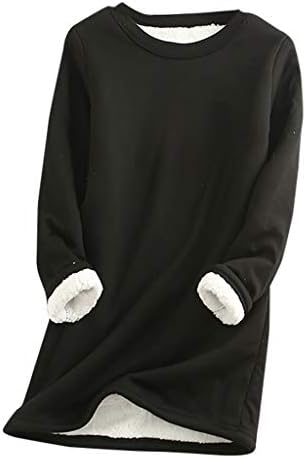
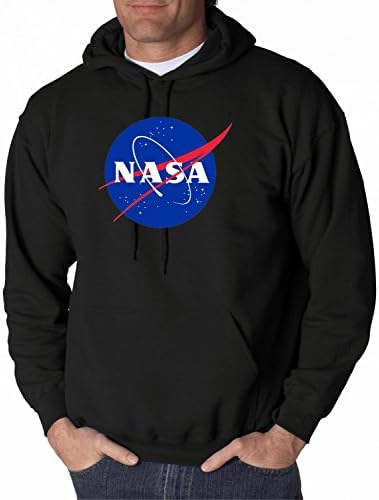
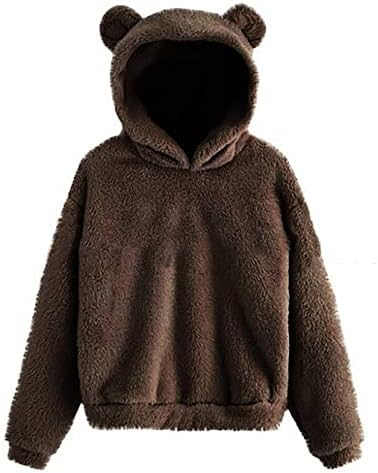


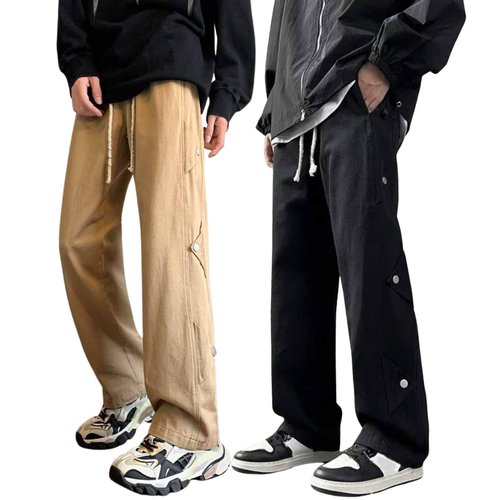
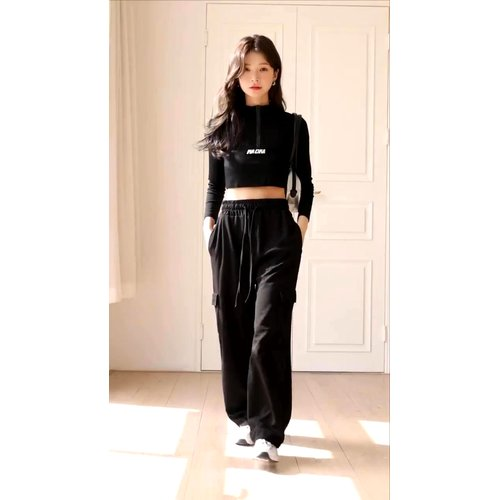
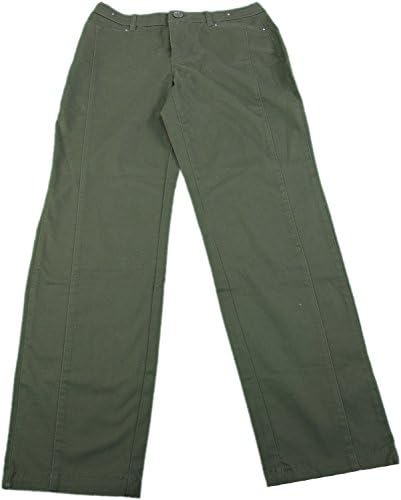


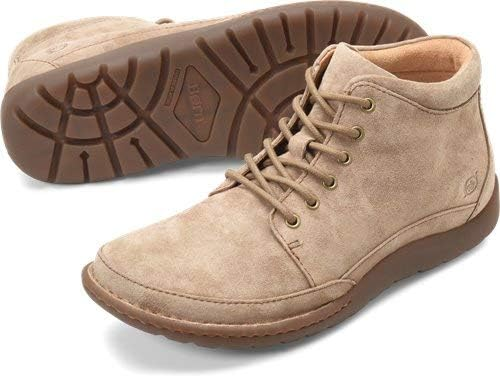
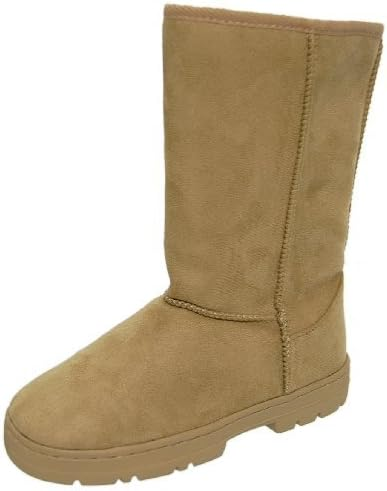
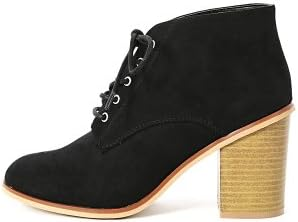

In [43]:
text_demo_result = run_text_demo(
    user_query=TEXT_QUERY,
    gender=TEXT_GENDER,
    profile=TEXT_PROFILE,
    include_products=ENABLE_LAYER_A_PRODUCTS,
)


### Thực thi và kiểm tra: coverage_gap_demo

- **Tác dụng chính:** Chạy phần luồng phối đồ Layer B V2 tương ứng và giữ các dòng in/hiển thị cần thiết để debug.
- **Đầu vào (Input):** Các biến cấu hình, dữ liệu mẫu và đối tượng đã được định nghĩa ở các cell phía trên.
- **Đầu ra (Output):** Biến kết quả cùng output debug như shape, ID, score, trace hoặc trạng thái dịch vụ.


In [44]:
print("=== Case cố ý kiểm tra coverage thiếu ===")
coverage_gap_demo = run_text_demo(
    user_query="Phối áo khoác nữ đi học mùa hè phong cách đơn giản",
    gender="female",
    profile={"dang_nguoi": "Dáng chữ nhật", "tone_da": "Da trung bình"},
    include_products=False,
)
assert coverage_gap_demo["base_result"]["status"] == "coverage_gap"
print("[PASS] Không trả rule mùa thu/đông cho yêu cầu mùa hè bị thiếu coverage.")


=== Case cố ý kiểm tra coverage thiếu ===
=== A. Intent có cấu trúc ===
{
  "action": "outfit_advice",
  "query": "Phối áo khoác nữ đi học mùa hè phong cách đơn giản",
  "genders": [
    "female"
  ],
  "base_slot": "Áo khoác ngoài",
  "season": "Hè",
  "occasion": "Học đường",
  "style": "Minimalist neutral",
  "body_type": "Dáng chữ nhật",
  "skin_tone": "Da trung bình",
  "has_image": false
}

=== B. Trạng thái retrieval ===
{
  "status": "coverage_gap",
  "message": "Knowledge chưa có rule thỏa các điều kiện cứng: ['base_slot', 'season', 'occasion']",
  "relaxed_constraints": []
}


""



=== C. Outfit Layer B ===


""


Cảnh báo: ["Knowledge chưa có rule thỏa các điều kiện cứng: ['base_slot', 'season', 'occasion']"]
[PASS] Không trả rule mùa thu/đông cho yêu cầu mùa hè bị thiếu coverage.


## BƯỚC 11: Demo ảnh

Nếu chỉ nhập ảnh mà không có từ khóa “phối”, chính sách retrieval mặc định trả sản phẩm giống ảnh. Nếu câu hỏi có yêu cầu phối đồ, chính sách này mới đi tiếp Layer B.

VLM chưa được gọi trực tiếp trong notebook vì endpoint VastAI của VLM chưa được cấu hình. V2 đã chỉ rõ lúc nào cần gọi VLM hoặc yêu cầu người dùng xác nhận món chủ đạo.

### Định nghĩa thành phần: IMAGE_QUERY_PATH, IMAGE_USER_QUERY, IMAGE_GENDER

- **Tác dụng chính:** Khai báo `IMAGE_QUERY_PATH`, `IMAGE_USER_QUERY`, `IMAGE_GENDER`, `IMAGE_PROFILE` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `IMAGE_QUERY_PATH`, `IMAGE_USER_QUERY`, `IMAGE_GENDER`, `IMAGE_PROFILE` để cell thực thi phía sau tái sử dụng.


In [45]:
IMAGE_QUERY_PATH = r""
IMAGE_USER_QUERY = "Món áo này phối thế nào để đi học mùa đông?"
IMAGE_GENDER = "all"
IMAGE_PROFILE = {"dang_nguoi": "Dáng chữ nhật", "tone_da": "Da trung bình"}


### Thực thi và kiểm tra: luồng phối đồ Layer B V2

- **Tác dụng chính:** Chạy phần luồng phối đồ Layer B V2 tương ứng và giữ các dòng in/hiển thị cần thiết để debug.
- **Đầu vào (Input):** Các biến cấu hình, dữ liệu mẫu và đối tượng đã được định nghĩa ở các cell phía trên.
- **Đầu ra (Output):** Biến kết quả cùng output debug như shape, ID, score, trace hoặc trạng thái dịch vụ.


In [46]:
if ENABLE_IMAGE_DEMO and IMAGE_QUERY_PATH.strip():
    image_demo_result = run_image_outfit_policy(
        image_path=IMAGE_QUERY_PATH,
        user_query=IMAGE_USER_QUERY,
        gender=IMAGE_GENDER,
        profile=IMAGE_PROFILE,
    )
    print(json.dumps({
        "status": image_demo_result.get("status"),
        "image_context": image_demo_result.get("image_context"),
        "message": image_demo_result.get("message", ""),
    }, ensure_ascii=False, indent=2))
    display_product_cards("Sản phẩm giống ảnh", image_demo_result.get("similar_products", []), limit=5)
    if image_demo_result.get("outfit"):
        display(outfit_table(image_demo_result["outfit"]))
else:
    print("[SKIP] Đặt ENABLE_IMAGE_DEMO=True và điền IMAGE_QUERY_PATH để chạy demo ảnh.")


[SKIP] Đặt ENABLE_IMAGE_DEMO=True và điền IMAGE_QUERY_PATH để chạy demo ảnh.


## BƯỚC 12: Regression test tối thiểu

Các test dưới đây kiểm tra parser, constraint cứng, profile của rule chi tiết và việc không đề xuất lại món chủ đạo. Đây chưa phải ground truth stylist; cần bổ sung một tập 50-100 query được chuyên gia gán nhãn để tính Recall@K, MRR và outfit coherence.

### Định nghĩa thành phần: intent_tests, parser_rows

- **Tác dụng chính:** Khai báo `intent_tests`, `parser_rows` cho bước luồng phối đồ Layer B V2; cell này chưa chủ động chạy pipeline nặng.
- **Đầu vào (Input):** Tham số được mô tả trong chữ ký hàm/lớp và các hằng cấu hình đã khai báo trước đó.
- **Đầu ra (Output):** Các hàm, lớp hoặc cấu hình `intent_tests`, `parser_rows` để cell thực thi phía sau tái sử dụng.


In [47]:
intent_tests = [
    ("Phối áo khoác đi học mùa đông", "Áo khoác ngoài", "Đông", "Học đường"),
    ("Quần này mặc đi làm mùa thu thế nào?", "Quần/Chân váy", "Thu", "Công sở"),
    ("Tìm giày cho chuyến du lịch mùa hè", "Giày dép", "Hè", "Du lịch"),
    ("Tôi muốn được tư vấn phong cách", None, None, None),
]

parser_rows = []


### Thực thi và kiểm tra: luồng phối đồ Layer B V2

- **Tác dụng chính:** Chạy phần luồng phối đồ Layer B V2 tương ứng và giữ các dòng in/hiển thị cần thiết để debug.
- **Đầu vào (Input):** Các biến cấu hình, dữ liệu mẫu và đối tượng đã được định nghĩa ở các cell phía trên.
- **Đầu ra (Output):** Biến kết quả cùng output debug như shape, ID, score, trace hoặc trạng thái dịch vụ.


In [48]:
for query, expected_slot, expected_season, expected_occasion in intent_tests:
    parsed = parse_outfit_constraints(query)
    passed = (
        parsed["base_slot"] == expected_slot
        and parsed["season"] == expected_season
        and parsed["occasion"] == expected_occasion
    )
    parser_rows.append({
        "query": query,
        "slot": parsed["base_slot"],
        "season": parsed["season"],
        "occasion": parsed["occasion"],
        "passed": passed,
    })
    assert passed, f"Intent parser sai với query: {query}"

display(pd.DataFrame(parser_rows))

if text_demo_result["outfit"].get("base_rule"):
    base_slot = text_demo_result["outfit"]["base_rule"]["outfit_slot"]
    assert base_slot not in text_demo_result["outfit"]["details"], "Outfit đang đề xuất lại món chủ đạo"
    for rule in text_demo_result["outfit"]["details"].values():
        assert profile_matches(rule, text_demo_result["intent"]), f"Rule chi tiết không hợp profile: {rule['rule_key']}"

print("[PASS] Regression test cơ bản đã hoàn tất.")


,query,slot,season,occasion,passed
0,Phối áo khoác đi học mùa đông,Áo khoác ngoài,Đông,Học đường,True
1,Quần này mặc đi làm mùa thu thế nào?,Quần/Chân váy,Thu,Công sở,True
2,Tìm giày cho chuyến du lịch mùa hè,Giày dép,Hè,Du lịch,True
3,Tôi muốn được tư vấn phong cách,None,None,None,True


[PASS] Regression test cơ bản đã hoàn tất.


## Kết luận và giới hạn còn lại

V2 xử lý được các lỗi logic chính của notebook cũ, nhưng chưa thay thế quy trình thẩm định dữ liệu:

- Các rule trong bảng `needs_review` cần người có chuyên môn xác nhận và sửa ở knowledge nguồn.
- Color harmony hiện là heuristic đơn giản vì Layer B chưa có trường màu/chất liệu/phom có cấu trúc.
- VLM chỉ nên chạy khi chính sách báo xung đột hoặc không chắc món chủ đạo. Cần cấu hình endpoint riêng trước khi tích hợp.
- Chất lượng cuối cùng phải được đo trên tập query có ground truth, không đánh giá bằng vài demo đẹp.

Khi V2 ổn định qua đánh giá, mới đồng bộ các hàm sang `app/core/outfit.py` để tránh notebook và ứng dụng chạy hai logic khác nhau.